
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

=== RESULTADOS DEL ESTADO n=3, l=0 (N=2000, r_max=40.0) ===
Energía obtenida (FDM) : -0.055554 Ha  (-1.5117 eV)
Valor teórico exacto    : -0.055556 Ha  (-1.5117 eV)


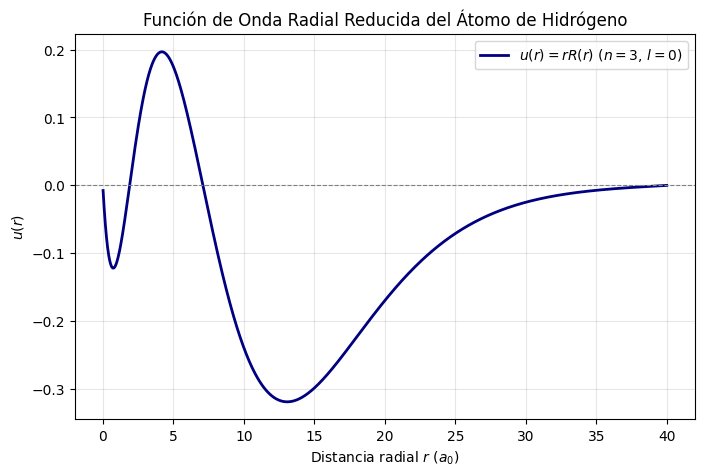

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import simpson


def hidrogeno(N=1000, r_max=20.0, l=0,nivel=0):
    h = r_max / (N + 1)
    r = np.linspace(h, r_max - h, N)
    diagonal = np.full(N, 1.0 / (h**2))
    alrededores = np.full(N - 1, -0.5 / (h**2))

    V = -1.0 / r + (l * (l + 1)) / (2.0 * r**2)

    H = (np.diag(diagonal + V) + np.diag(alrededores, k=1) + np.diag(alrededores, k=-1))

    energias, autovectores = np.linalg.eigh(H)

    u_0 = autovectores[:, nivel]
    norma = np.sqrt(simpson(u_0**2, x=r))
    u_0 = u_0 / norma

    return r, energias, u_0


N = 2000
r_max = 40.0
l = 0
nivel = 2
r, energias, u = hidrogeno(N,r_max, l,nivel)

n = l + 1 + nivel
E_exacta = -1.0 / (2 * n**2)

E = energias[nivel]
E_ev = E * 27.2114 #transformacion de unidades naturales a ekectro volts

print(f"=== RESULTADOS DEL ESTADO n={n}, l={l} (N={N}, r_max={r_max}) ===")
print(f"Energía obtenida (FDM) : {E:.6f} Ha  ({E_ev:.4f} eV)")
print(f"Valor teórico exacto    : {E_exacta:.6f} Ha  ({E_exacta*27.2114:.4f} eV)")

plt.figure(figsize=(8, 5))
plt.plot(r,u,label=rf"$u(r) = r R(r)$ ($n={n}$, $l={l}$)",color="navy",linewidth=2,)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Función de Onda Radial Reducida del Átomo de Hidrógeno")
plt.xlabel(r"Distancia radial $r$ ($a_0$)")
plt.ylabel(r"$u(r)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()